# Notebook 6 — Harmonised Cross-Model Comparison and Final Development Candidate Selection

This notebook compares only the **final harmonised development outputs** from:

1. Notebook 3 — LightGBM
2. Notebook 4 — LSTM
3. Notebook 5 — CNN-LSTM

It does **not** retrain any model, alter any overlay, or access the final holdout. Its purpose is to:

- verify that the three model families used the same chronological evaluation framework;
- compare all 12 model tracks under the same cost and risk assumptions;
- distinguish active trading performance from risk-gated stay-flat behaviour;
- compare classification on native and common timestamps;
- reconstruct development equity curves from frozen test predictions and validation-selected overlays;
- apply a fixed, transparent candidate-selection hierarchy;
- select exactly one candidate to advance to the untouched 2025–2026 holdout.

The final holdout from **2025-01-01 to 2026-03-31 remains untouched**.

> Important: selection in this notebook means *advance to final holdout evaluation*. It does not mean that profitability or deployment readiness has already been established.

## Methodological justification and research references

### Time-ordered performance estimation

Financial time series are non-stationary and temporally dependent. The final model notebooks therefore used repeated ordered out-of-sample periods rather than shuffled validation. Cerqueira, Torgo and Mozetič report that out-of-sample procedures preserving temporal order are particularly appropriate when non-stationary variation is present.

### Separating selection from final evaluation

Model selection can overfit the criterion used to choose the winner. Cawley and Talbot show that overfitting can occur at the model-selection level even when individual models are regularised. Bailey et al. similarly warn that searching among many historical trading configurations can select an apparently strong backtest that degrades out of sample.

Notebook 6 therefore:

- uses only already-frozen development outputs;
- does not alter model or overlay parameters;
- uses a written selection policy before accessing the final holdout;
- selects one candidate only;
- treats common-timestamp classification as a secondary diagnostic, while native deployment trading performance remains primary.

### Why no formal winner-take-all significance claim is made here

There are only three annual development test folds. Fold-level hypothesis testing with such a small number of periods would create false precision. This notebook reports fold stability, common-timestamp predictive metrics, cost robustness, drawdown and validation-to-test decay. Stronger statistical conclusions are deferred to the untouched final holdout and the final evaluation stage.

### References

- Cawley, G. C., & Talbot, N. L. C. (2010). *On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation*. Journal of Machine Learning Research, 11, 2079–2107. https://www.jmlr.org/papers/volume11/cawley10a/cawley10a.pdf
- Cerqueira, V., Torgo, L., & Mozetič, I. (2020). *Evaluating time series forecasting models: an empirical study on performance estimation methods*. Machine Learning, 109, 1997–2028. https://doi.org/10.1007/s10994-020-05910-7
- Bailey, D. H., Borwein, J. M., López de Prado, M., & Zhu, Q. J. (2016). *The Probability of Backtest Overfitting*. Journal of Computational Finance, 20(4), 39–69. https://doi.org/10.21314/JCF.2016.322
- Diebold, F. X., & Mariano, R. S. (1995). *Comparing Predictive Accuracy*. Journal of Business & Economic Statistics, 13(3), 253–263. https://doi.org/10.1080/07350015.1995.10524599

## 1. Setup

This notebook is lightweight and should run on CPU. It reads existing CSV/JSON outputs only.

In [1]:
from __future__ import annotations

import importlib.util
import json
import math
import os
import subprocess
import sys
from pathlib import Path
from typing import Any

for package_name, pip_name in [
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"),
]:
    if importlib.util.find_spec(package_name) is None:
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import balanced_accuracy_score, brier_score_loss, log_loss, roc_auc_score

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
print('Running in Colab:', IN_COLAB)

Mounted at /content/drive
Running in Colab: True


In [2]:
# ============================
# Fixed Notebook 6 configuration
# ============================

NOTEBOOK_CONFIG_VERSION = '06_cross_model_selection_v1_2026-06-17'
DEFAULT_PROJECT_ROOT = '/content/drive/MyDrive/fyp_master_starter' if IN_COLAB else str(Path('.').resolve())
PROJECT_ROOT = Path(os.environ.get('CAPSTONE_PROJECT_ROOT', DEFAULT_PROJECT_ROOT)).resolve()

NOTEBOOK_OUTPUT_ROOT = PROJECT_ROOT / 'data' / 'capstone_methodology' / 'notebook_outputs'
OUTPUT_DIR = NOTEBOOK_OUTPUT_ROOT / '06_m15_harmonised_cross_model_comparison'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
CONFIG_DIR = OUTPUT_DIR / 'configuration'
for directory in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, CONFIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_SPECS = {
    'LightGBM': {
        'model_family_key': 'lightgbm',
        'source_dir': NOTEBOOK_OUTPUT_ROOT / '03_m15_lightgbm_walkforward_full_harmonised',
    },
    'LSTM': {
        'model_family_key': 'lstm',
        'source_dir': NOTEBOOK_OUTPUT_ROOT / '04_m15_lstm_walkforward_full_harmonised',
    },
    'CNN-LSTM': {
        'model_family_key': 'cnn_lstm',
        'source_dir': NOTEBOOK_OUTPUT_ROOT / '05_m15_cnn_lstm_walkforward_full',
    },
}

TRACK_ORDER = [
    'vanilla_price_only',
    'vanilla_volume_assisted',
    'tuned_price_only',
    'tuned_volume_assisted',
]
COST_GRID_BPS = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
MAIN_COST_BPS = 1.0
EXPECTED_BAR_DELTA = pd.Timedelta(minutes=15)
DAILY_LOSS_STOP = -0.02
TOTAL_DRAWDOWN_STOP = -0.15
FINAL_HOLDOUT_START = pd.Timestamp('2025-01-01', tz='UTC')

# Candidate-selection policy. This is intentionally fixed before the final holdout is opened.
SELECTION_POLICY = {
    'strict_eligibility': {
        'mean_net_return_1bps_gt': 0.0,
        'mean_net_return_0_5bps_gt': 0.0,
        'minimum_active_folds': 2,
        'minimum_positive_folds': 1,
        'mean_max_drawdown_gt': TOTAL_DRAWDOWN_STOP,
        'exclude_all_stay_flat': True,
    },
    'lexicographic_ranking': [
        'mean_net_return_1bps_desc',
        'positive_fold_count_desc',
        'worst_fold_net_return_desc',
        'mean_absolute_validation_to_test_decay_asc',
        'mean_max_drawdown_desc',
        'turnover_units_per_day_asc',
        'mean_roc_auc_desc',
    ],
    'fallback_tiers': [
        'positive at 0.5 bps with at least two active folds',
        'positive at 0 bps with at least two active folds',
        'best active track with at least two active folds',
    ],
}

print('Project root:', PROJECT_ROOT)
print('Output directory:', OUTPUT_DIR)

Project root: /content/drive/MyDrive/fyp_master_starter
Output directory: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/06_m15_harmonised_cross_model_comparison


## 2. Source integrity and framework parity gate

The notebook stops if a required harmonised source output is missing or if the shared cost, overlay, risk or fold definitions differ.

In [3]:
REQUIRED_TABLES = [
    'aggregate_test_trading_summary_by_cost.csv',
    'aggregate_test_classification_summary.csv',
    'test_trading_metrics_by_fold_cost.csv',
    'selected_overlay_by_fold.csv',
    'validation_to_test_decay_summary_at_main_cost.csv',
    'validation_to_test_decay_by_fold_at_main_cost.csv',
    'calibration_baseline_comparison.csv',
    'test_predictions_by_track_fold.csv',
    'track_summary_at_main_cost.csv',
]

SHARED_CONFIG_KEYS = [
    'folds',
    'inner_validation_years',
    'main_selection_cost_bps',
    'cost_grid_bps',
    'threshold_grid',
    'min_hold_grid',
    'max_position_change_events_per_day_grid',
    'daily_loss_stop',
    'total_drawdown_stop',
    'min_validation_trades',
    'fast_debug',
]

def load_json(path: Path) -> dict[str, Any]:
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)

source_data: dict[str, dict[str, Any]] = {}
manifest_rows = []

for family, spec in SOURCE_SPECS.items():
    source_dir = Path(spec['source_dir'])
    table_dir = source_dir / 'tables'
    config_path = source_dir / 'configuration' / 'run_config.json'
    missing = [str(table_dir / name) for name in REQUIRED_TABLES if not (table_dir / name).exists()]
    if not config_path.exists():
        missing.append(str(config_path))
    if missing:
        raise FileNotFoundError(
            f"Missing required harmonised outputs for {family}:\n" + '\n'.join(missing)
        )

    tables = {}
    for name in REQUIRED_TABLES:
        parse_dates = ['time'] if name == 'test_predictions_by_track_fold.csv' else None
        tables[name] = pd.read_csv(table_dir / name, parse_dates=parse_dates)

    config_payload = load_json(config_path)
    critical_config = config_payload['critical_config']
    source_data[family] = {
        'source_dir': source_dir,
        'tables': tables,
        'config': critical_config,
        'fingerprint': config_payload.get('config_fingerprint'),
        'model_family_key': spec['model_family_key'],
    }

    manifest_rows.append({
        'model_family': family,
        'model_family_key': spec['model_family_key'],
        'source_dir': str(source_dir),
        'config_fingerprint': config_payload.get('config_fingerprint'),
        'prediction_rows': len(tables['test_predictions_by_track_fold.csv']),
        'tracks': ', '.join(sorted(tables['aggregate_test_classification_summary.csv']['track'].unique())),
    })

# Shared framework parity
reference_family = 'LightGBM'
reference_config = source_data[reference_family]['config']
parity_rows = []
for key in SHARED_CONFIG_KEYS:
    reference_value = reference_config.get(key)
    row = {'config_key': key, reference_family: json.dumps(reference_value, sort_keys=True)}
    all_equal = True
    for family in ['LSTM', 'CNN-LSTM']:
        value = source_data[family]['config'].get(key)
        row[family] = json.dumps(value, sort_keys=True)
        all_equal &= value == reference_value
    row['all_equal'] = bool(all_equal)
    parity_rows.append(row)

framework_parity = pd.DataFrame(parity_rows)
if not framework_parity['all_equal'].all():
    display(framework_parity[~framework_parity['all_equal']])
    raise AssertionError('The harmonised source notebooks do not share the same evaluation framework.')

# Track and holdout checks
for family, payload in source_data.items():
    tracks = set(payload['tables']['aggregate_test_classification_summary.csv']['track'])
    if tracks != set(TRACK_ORDER):
        raise AssertionError(f'{family}: unexpected track set {tracks}')
    predictions = payload['tables']['test_predictions_by_track_fold.csv']
    if predictions['time'].max() >= FINAL_HOLDOUT_START:
        raise AssertionError(f'{family}: final holdout appears in development predictions.')
    if predictions.duplicated(['track', 'fold', 'time']).any():
        raise AssertionError(f'{family}: duplicate prediction keys detected.')

source_manifest = pd.DataFrame(manifest_rows)
source_manifest.to_csv(TABLE_DIR / 'source_manifest.csv', index=False)
framework_parity.to_csv(TABLE_DIR / 'framework_parity_audit.csv', index=False)

print('Framework parity: PASS')
display(source_manifest)
display(framework_parity)

Framework parity: PASS


,model_family,model_family_key,source_dir,config_fingerprint,prediction_rows,tracks
0,LightGBM,lightgbm,/content/drive/MyDrive/fyp_master_starter/data...,5bf38ebc705299d479c013c7351fc1252268cbaabeea5a...,278628,"tuned_price_only, tuned_volume_assisted, vanil..."
1,LSTM,lstm,/content/drive/MyDrive/fyp_master_starter/data...,ea940c219a22cda55467add97eae5aa8482cca9212ba5c...,138138,"tuned_price_only, tuned_volume_assisted, vanil..."
2,CNN-LSTM,cnn_lstm,/content/drive/MyDrive/fyp_master_starter/data...,1d094f532ba08b52f1495836073504774ad18c1783508b...,125808,"tuned_price_only, tuned_volume_assisted, vanil..."


,config_key,LightGBM,LSTM,CNN-LSTM,all_equal
0,folds,"[{""fold"": 1, ""test_end"": ""2023-01-01 00:00:00+...","[{""fold"": 1, ""test_end"": ""2023-01-01 00:00:00+...","[{""fold"": 1, ""test_end"": ""2023-01-01 00:00:00+...",True
1,inner_validation_years,1,1,1,True
2,main_selection_cost_bps,1.0,1.0,1.0,True
3,cost_grid_bps,"[0.0, 0.5, 1.0, 2.0, 3.0, 5.0]","[0.0, 0.5, 1.0, 2.0, 3.0, 5.0]","[0.0, 0.5, 1.0, 2.0, 3.0, 5.0]",True
4,threshold_grid,"[[0.51, 0.49], [0.52, 0.48], [0.53, 0.47], [0....","[[0.51, 0.49], [0.52, 0.48], [0.53, 0.47], [0....","[[0.51, 0.49], [0.52, 0.48], [0.53, 0.47], [0....",True
5,min_hold_grid,"[1, 2, 3]","[1, 2, 3]","[1, 2, 3]",True
6,max_position_change_events_per_day_grid,"[3, 5, 8]","[3, 5, 8]","[3, 5, 8]",True
7,daily_loss_stop,-0.02,-0.02,-0.02,True
8,total_drawdown_stop,-0.15,-0.15,-0.15,True
9,min_validation_trades,20,20,20,True


## 3. Build the cross-model master table

Native trading performance is primary because it represents how each frozen model-plus-overlay system would actually behave. Classification metrics are retained as secondary evidence.

In [4]:
def estimate_breakeven_cost(costs: np.ndarray, returns: np.ndarray) -> float:
    order = np.argsort(costs)
    costs = np.asarray(costs)[order].astype(float)
    returns = np.asarray(returns)[order].astype(float)
    if np.all(returns < 0):
        return 0.0
    if np.all(returns >= 0):
        return float(costs.max())
    for i in range(len(costs) - 1):
        r0, r1 = returns[i], returns[i + 1]
        if r0 >= 0 and r1 < 0:
            c0, c1 = costs[i], costs[i + 1]
            if r1 == r0:
                return float(c0)
            return float(c0 + (0 - r0) * (c1 - c0) / (r1 - r0))
    return float(costs[returns >= 0].max())

master_rows = []
fold_rows = []
all_trading_cost_rows = []
all_classification_rows = []
all_decay_fold_rows = []
all_overlay_rows = []

for family, payload in source_data.items():
    tables = payload['tables']
    trading = tables['aggregate_test_trading_summary_by_cost.csv'].copy()
    classification = tables['aggregate_test_classification_summary.csv'].copy()
    fold_trading = tables['test_trading_metrics_by_fold_cost.csv'].copy()
    overlays = tables['selected_overlay_by_fold.csv'].copy()
    decay_summary = tables['validation_to_test_decay_summary_at_main_cost.csv'].copy()
    decay_fold = tables['validation_to_test_decay_by_fold_at_main_cost.csv'].copy()
    calibration = tables['calibration_baseline_comparison.csv'].copy()

    for df in [trading, classification, fold_trading, overlays, decay_summary, decay_fold, calibration]:
        df['model_family_display'] = family

    all_trading_cost_rows.append(trading)
    all_classification_rows.append(classification)
    all_decay_fold_rows.append(decay_fold)
    all_overlay_rows.append(overlays)

    for track in TRACK_ORDER:
        tcurve = trading[trading['track'] == track].sort_values('cost_bps')
        main = tcurve[np.isclose(tcurve['cost_bps'], MAIN_COST_BPS)].iloc[0]
        cls = classification[classification['track'] == track].iloc[0]
        ov = overlays[overlays['track'] == track]
        dec = decay_summary[decay_summary['track'] == track].iloc[0]
        cal = calibration[calibration['track'] == track].iloc[0]
        folds = fold_trading[
            (fold_trading['track'] == track)
            & np.isclose(fold_trading['cost_bps'], MAIN_COST_BPS)
        ].sort_values('fold')
        dec_folds = decay_fold[decay_fold['track'] == track]

        active_folds = int((ov['selected_action'] == 'trade').sum())
        stay_flat_folds = int((ov['selected_action'] == 'stay_flat').sum())
        positive_fold_count = int((folds['net_return'] > 0).sum())

        row = {
            'model_family': family,
            'model_family_key': payload['model_family_key'],
            'track': track,
            'feature_set': main['feature_set'],
            'mode': main['mode'],
            'display_name': f"{family} | {track.replace('_', ' ')}",
            'mean_net_return_0bps': float(tcurve.loc[np.isclose(tcurve['cost_bps'], 0.0), 'mean_net_return'].iloc[0]),
            'mean_net_return_0_5bps': float(tcurve.loc[np.isclose(tcurve['cost_bps'], 0.5), 'mean_net_return'].iloc[0]),
            'mean_net_return_1bps': float(main['mean_net_return']),
            'mean_net_return_2bps': float(tcurve.loc[np.isclose(tcurve['cost_bps'], 2.0), 'mean_net_return'].iloc[0]),
            'mean_gross_return_1bps': float(main['mean_gross_return']),
            'mean_sharpe_1bps': float(main['mean_sharpe']),
            'mean_sortino_1bps': float(main['mean_sortino']),
            'mean_max_drawdown_1bps': float(main['mean_max_drawdown']),
            'mean_turnover_units_per_day_1bps': float(main['mean_turnover_units_per_day']),
            'mean_position_change_events_per_day_1bps': float(main['mean_position_change_events_per_day']),
            'mean_trade_count_1bps': float(main['mean_trade_count']),
            'mean_active_rate_1bps': float(main['mean_active_rate']),
            'mean_profit_factor_1bps': float(main['mean_profit_factor']),
            'positive_fold_rate_1bps': float(main['positive_fold_rate']),
            'positive_fold_count_1bps': positive_fold_count,
            'active_fold_count': active_folds,
            'stay_flat_fold_count': stay_flat_folds,
            'selected_trade_rate': active_folds / 3.0,
            'all_stay_flat': active_folds == 0,
            'worst_fold_net_return_1bps': float(folds['net_return'].min()),
            'best_fold_net_return_1bps': float(folds['net_return'].max()),
            'std_fold_net_return_1bps': float(folds['net_return'].std(ddof=1)),
            'drawdown_stop_count_1bps': int(folds['total_drawdown_stop_triggered'].sum()),
            'mean_roc_auc': float(cls['mean_roc_auc']),
            'std_roc_auc': float(cls['std_roc_auc']),
            'mean_balanced_accuracy': float(cls['mean_balanced_accuracy']),
            'mean_brier_improvement_vs_baseline': float(cal['mean_brier_improvement_vs_baseline']),
            'mean_log_loss_improvement_vs_baseline': float(cal['mean_log_loss_improvement_vs_baseline']),
            'mean_validation_selected_net_return': float(dec['mean_validation_selected_net_return']),
            'mean_net_return_decay': float(dec['mean_net_return_decay']),
            'mean_absolute_validation_to_test_decay': float(dec_folds['net_return_decay_test_minus_validation'].abs().mean()),
            'breakeven_cost_bps': estimate_breakeven_cost(tcurve['cost_bps'].to_numpy(), tcurve['mean_net_return'].to_numpy()),
        }
        master_rows.append(row)

        fold_copy = folds.copy()
        fold_copy['model_family'] = family
        fold_copy['display_name'] = row['display_name']
        fold_rows.append(fold_copy)

track_master = pd.DataFrame(master_rows)
fold_main_cost = pd.concat(fold_rows, ignore_index=True)
trading_cost_all = pd.concat(all_trading_cost_rows, ignore_index=True)
classification_all = pd.concat(all_classification_rows, ignore_index=True)
decay_fold_all = pd.concat(all_decay_fold_rows, ignore_index=True)
overlay_all = pd.concat(all_overlay_rows, ignore_index=True)

track_master.to_csv(TABLE_DIR / 'cross_model_track_master.csv', index=False)
fold_main_cost.to_csv(TABLE_DIR / 'fold_level_main_cost_comparison.csv', index=False)
trading_cost_all.to_csv(TABLE_DIR / 'cross_model_trading_by_cost.csv', index=False)
classification_all.to_csv(TABLE_DIR / 'cross_model_classification_native.csv', index=False)
decay_fold_all.to_csv(TABLE_DIR / 'cross_model_validation_to_test_decay_by_fold.csv', index=False)
overlay_all.to_csv(TABLE_DIR / 'cross_model_selected_overlays.csv', index=False)

summary_cols = [
    'model_family', 'track', 'mean_net_return_0bps', 'mean_net_return_0_5bps',
    'mean_net_return_1bps', 'mean_sharpe_1bps', 'mean_max_drawdown_1bps',
    'positive_fold_count_1bps', 'active_fold_count', 'mean_roc_auc',
    'mean_absolute_validation_to_test_decay', 'breakeven_cost_bps',
]
display(track_master[summary_cols].sort_values('mean_net_return_1bps', ascending=False))

,model_family,track,mean_net_return_0bps,mean_net_return_0_5bps,mean_net_return_1bps,mean_sharpe_1bps,mean_max_drawdown_1bps,positive_fold_count_1bps,active_fold_count,mean_roc_auc,mean_absolute_validation_to_test_decay,breakeven_cost_bps
9,CNN-LSTM,vanilla_volume_assisted,0.103714,0.065665,0.022578,-0.039717,-0.095158,1,2,0.517166,0.113332,1.544921
10,CNN-LSTM,tuned_price_only,0.039113,0.021453,0.003357,0.045856,-0.043166,1,1,0.521358,0.015441,1.103795
6,LSTM,tuned_price_only,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.518844,0.000000,5.000000
5,LSTM,vanilla_volume_assisted,0.031192,-0.004253,-0.038586,-0.571939,-0.071587,1,2,0.515659,0.068569,0.440003
11,CNN-LSTM,tuned_volume_assisted,0.014909,-0.013415,-0.048758,-0.975705,-0.060839,0,2,0.522854,0.061607,0.263189
4,LSTM,vanilla_price_only,0.020215,-0.025725,-0.057770,-1.211574,-0.100005,0,2,0.522127,0.109818,0.220016
3,LightGBM,tuned_volume_assisted,-0.000665,-0.037161,-0.061695,-0.756453,-0.093117,0,2,0.521729,0.142715,0.000000
2,LightGBM,tuned_price_only,-0.013817,-0.043343,-0.072563,-1.245366,-0.133406,1,3,0.521846,0.155290,0.000000
7,LSTM,tuned_volume_assisted,-0.037293,-0.062950,-0.080353,-1.417922,-0.102901,0,2,0.519233,0.195159,0.000000
1,LightGBM,vanilla_volume_assisted,-0.060657,-0.073945,-0.082207,-1.000824,-0.100147,0,2,0.520335,0.159619,0.000000


## 4. Native trading comparison and report-ready figures

These figures use each system's native prediction coverage and frozen overlay. They are the primary deployment-oriented comparison.

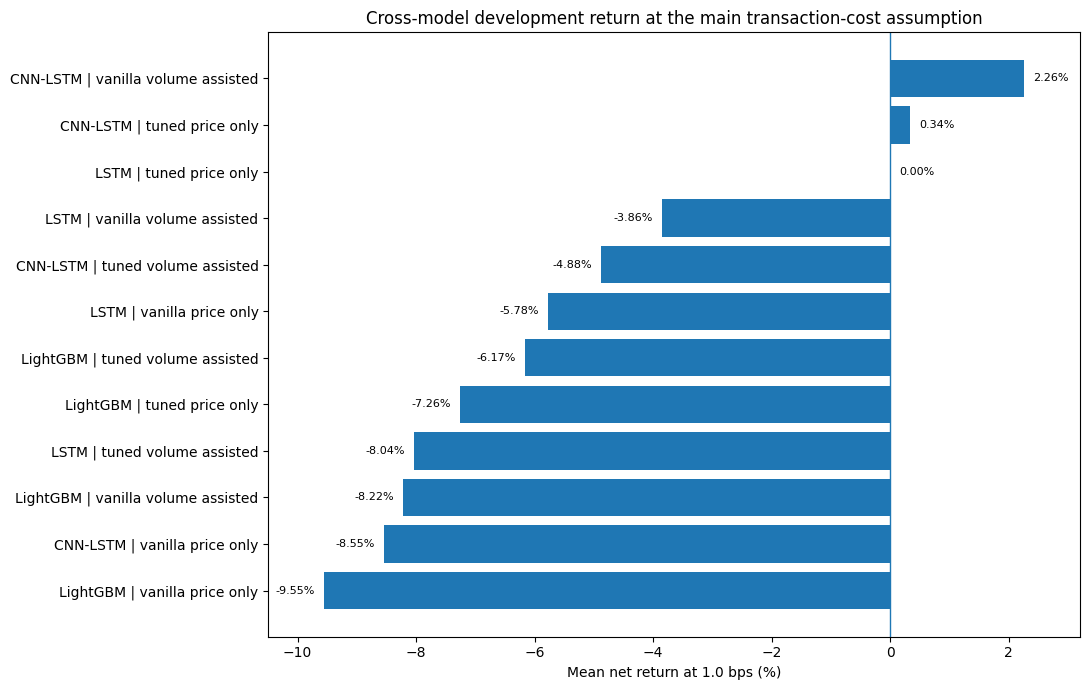

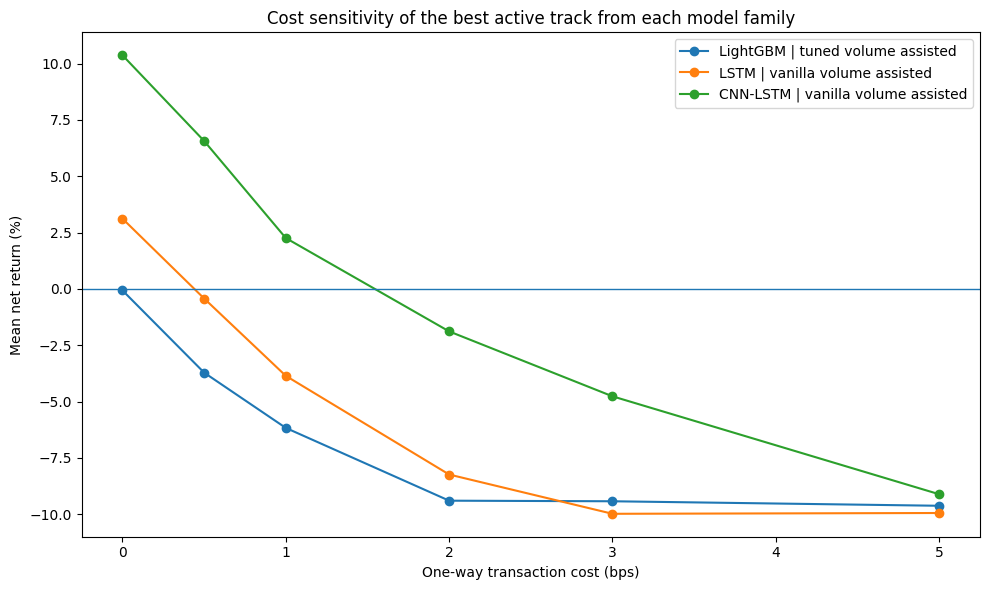

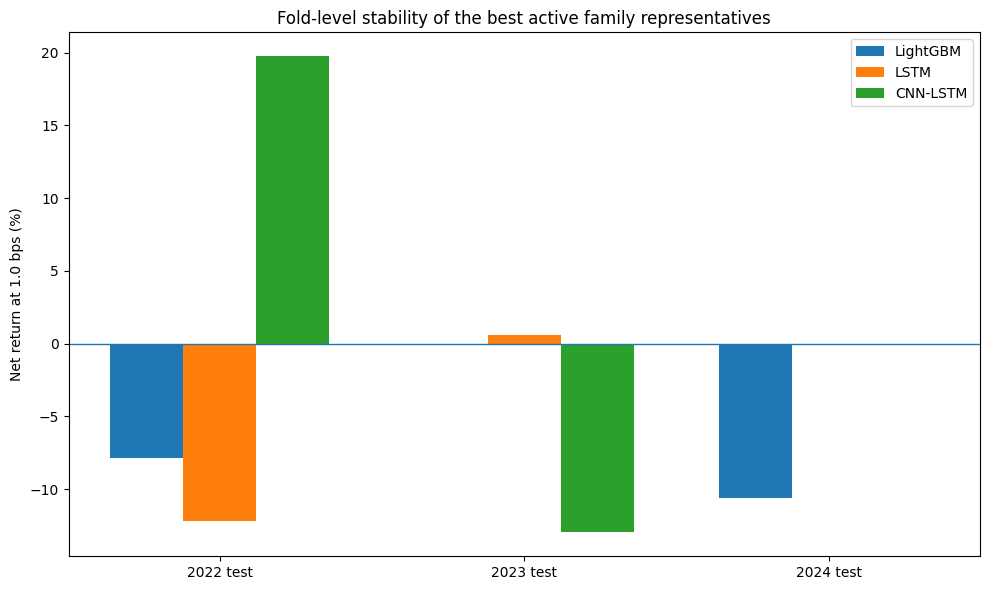

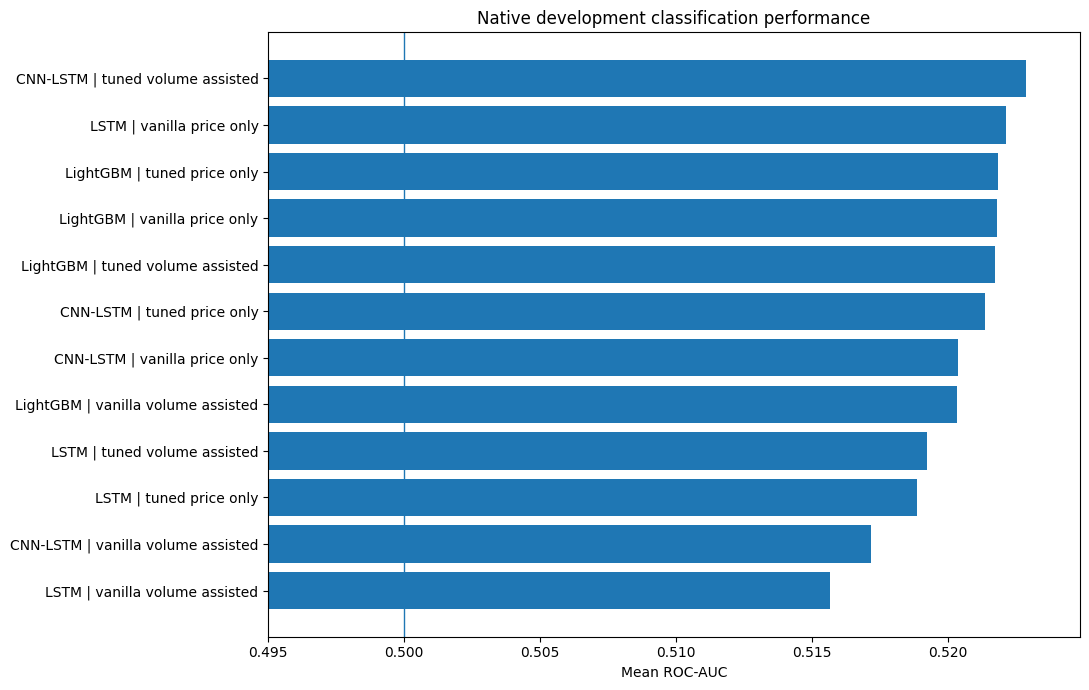

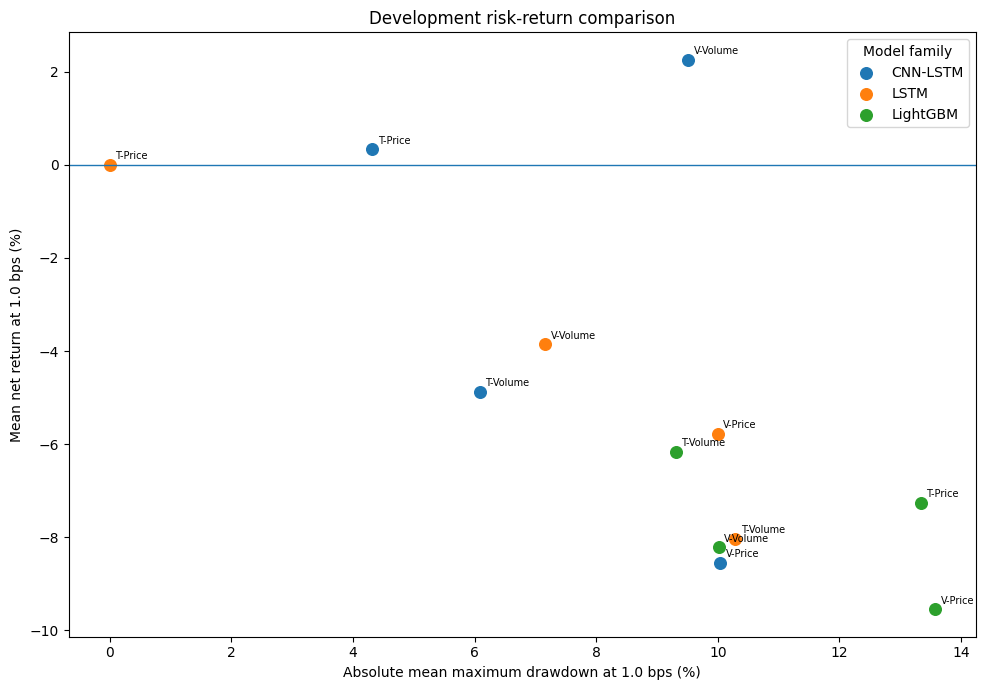

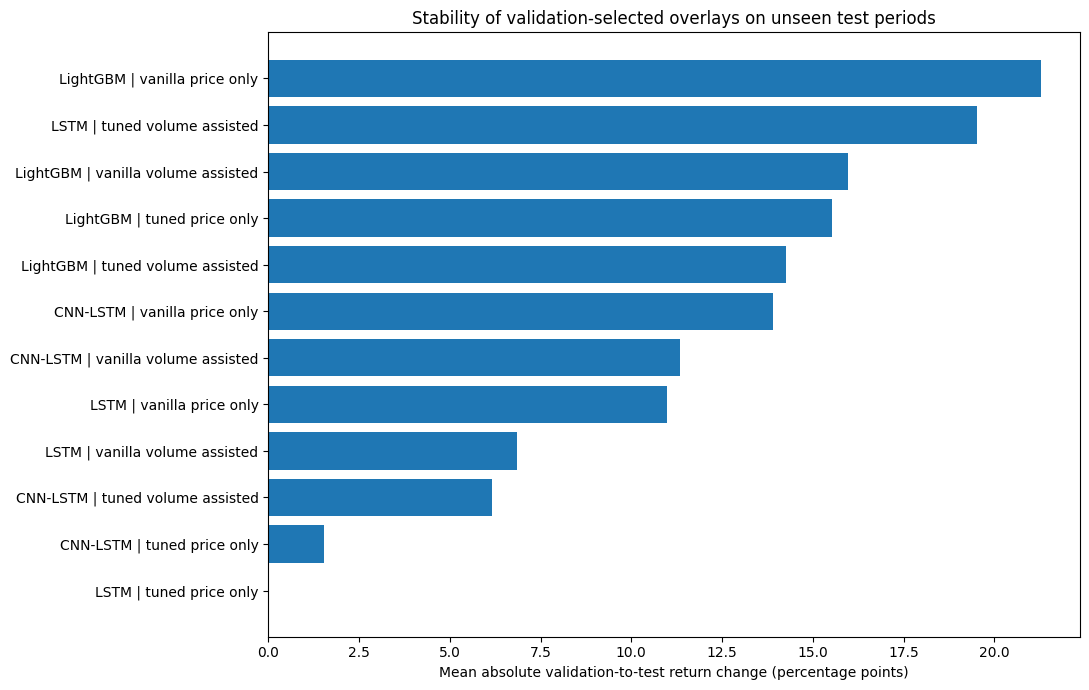

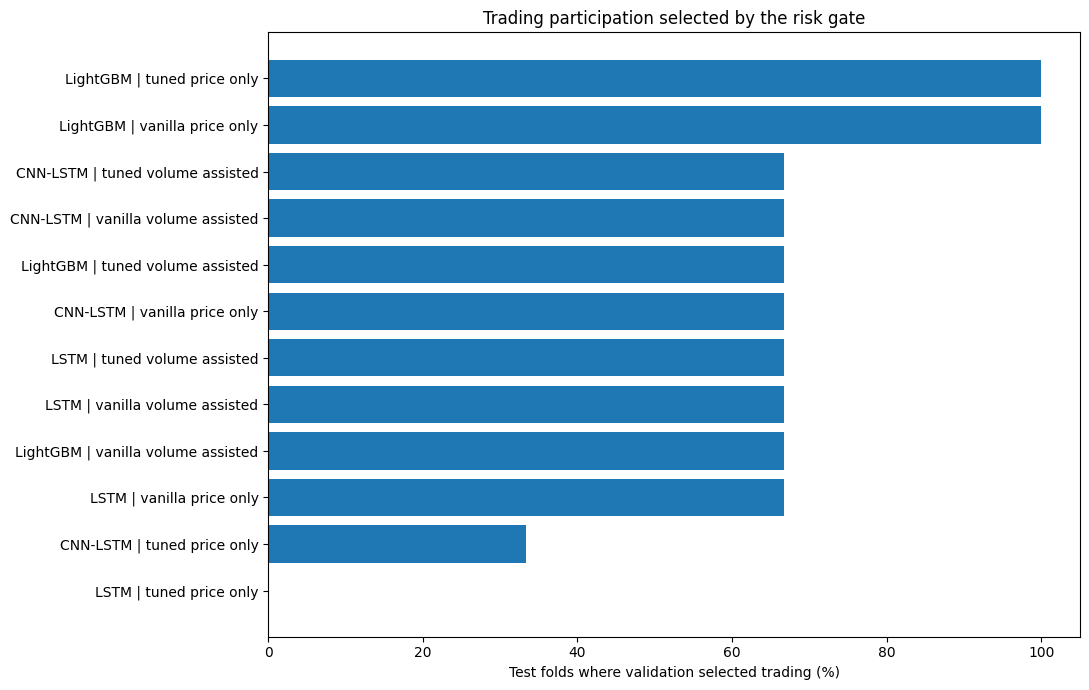

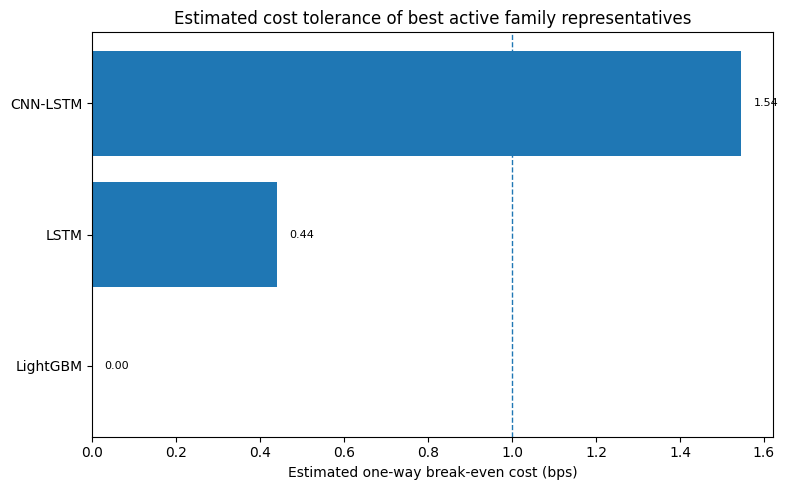

,model_family,track,mean_net_return_0bps,mean_net_return_0_5bps,mean_net_return_1bps,mean_sharpe_1bps,mean_max_drawdown_1bps,positive_fold_count_1bps,active_fold_count,mean_roc_auc,mean_absolute_validation_to_test_decay,breakeven_cost_bps
0,LightGBM,tuned_volume_assisted,-0.000665,-0.037161,-0.061695,-0.756453,-0.093117,0,2,0.521729,0.142715,0.000000
1,LSTM,vanilla_volume_assisted,0.031192,-0.004253,-0.038586,-0.571939,-0.071587,1,2,0.515659,0.068569,0.440003
2,CNN-LSTM,vanilla_volume_assisted,0.103714,0.065665,0.022578,-0.039717,-0.095158,1,2,0.517166,0.113332,1.544921


,model_family,track,mean_net_return_0bps,mean_net_return_0_5bps,mean_net_return_1bps,mean_sharpe_1bps,mean_max_drawdown_1bps,positive_fold_count_1bps,active_fold_count,mean_roc_auc,mean_absolute_validation_to_test_decay,breakeven_cost_bps
0,LightGBM,tuned_volume_assisted,-0.000665,-0.037161,-0.061695,-0.756453,-0.093117,0,2,0.521729,0.142715,0.000000
1,LSTM,tuned_price_only,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.518844,0.000000,5.000000
2,CNN-LSTM,vanilla_volume_assisted,0.103714,0.065665,0.022578,-0.039717,-0.095158,1,2,0.517166,0.113332,1.544921


In [5]:
def save_figure(fig: plt.Figure, stem: str) -> None:
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIGURE_DIR / f'{stem}.svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)

# Best active representative per family: at least two active folds, then highest 1 bps mean return.
best_active_rows = []
best_risk_gated_rows = []
for family in SOURCE_SPECS:
    family_df = track_master[track_master['model_family'] == family].copy()
    active_pool = family_df[family_df['active_fold_count'] >= 2].copy()
    if active_pool.empty:
        active_pool = family_df[family_df['active_fold_count'] >= 1].copy()
    best_active_rows.append(active_pool.sort_values('mean_net_return_1bps', ascending=False).iloc[0])
    best_risk_gated_rows.append(family_df.sort_values('mean_net_return_1bps', ascending=False).iloc[0])

best_active_by_family = pd.DataFrame(best_active_rows).reset_index(drop=True)
best_risk_gated_by_family = pd.DataFrame(best_risk_gated_rows).reset_index(drop=True)
best_active_by_family.to_csv(TABLE_DIR / 'best_active_track_by_family.csv', index=False)
best_risk_gated_by_family.to_csv(TABLE_DIR / 'best_risk_gated_track_by_family.csv', index=False)

# Figure 1: all tracks at main cost
plot_df = track_master.sort_values('mean_net_return_1bps')
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_df['display_name'], plot_df['mean_net_return_1bps'] * 100)
ax.axvline(0, linewidth=1)
ax.set_xlabel('Mean net return at 1.0 bps (%)')
ax.set_title('Cross-model development return at the main transaction-cost assumption')
margin = max(0.8, (plot_df['mean_net_return_1bps'].max() - plot_df['mean_net_return_1bps'].min()) * 100 * 0.08)
ax.set_xlim(plot_df['mean_net_return_1bps'].min() * 100 - margin, plot_df['mean_net_return_1bps'].max() * 100 + margin)
for i, value in enumerate(plot_df['mean_net_return_1bps'] * 100):
    ax.text(value + (0.15 if value >= 0 else -0.15), i, f'{value:.2f}%', va='center', ha='left' if value >= 0 else 'right', fontsize=8)
save_figure(fig, 'cross_model_all_tracks_net_return_1bps')

# Figure 2: cost curves for best active family representatives
fig, ax = plt.subplots(figsize=(10, 6))
for _, rep in best_active_by_family.iterrows():
    curve = trading_cost_all[
        (trading_cost_all['model_family_display'] == rep['model_family'])
        & (trading_cost_all['track'] == rep['track'])
    ].sort_values('cost_bps')
    ax.plot(curve['cost_bps'], curve['mean_net_return'] * 100, marker='o', label=f"{rep['model_family']} | {rep['track'].replace('_', ' ')}")
ax.axhline(0, linewidth=1)
ax.set_xlabel('One-way transaction cost (bps)')
ax.set_ylabel('Mean net return (%)')
ax.set_title('Cost sensitivity of the best active track from each model family')
ax.legend()
save_figure(fig, 'best_active_by_family_cost_curve')

# Figure 3: fold returns at 1 bps
rep_keys = set(zip(best_active_by_family['model_family'], best_active_by_family['track']))
fold_plot = fold_main_cost[
    fold_main_cost.apply(lambda r: (r['model_family'], r['track']) in rep_keys, axis=1)
].copy()
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.24
folds = np.array([1, 2, 3])
for j, (_, rep) in enumerate(best_active_by_family.iterrows()):
    x = fold_plot[(fold_plot['model_family'] == rep['model_family']) & (fold_plot['track'] == rep['track'])].sort_values('fold')
    ax.bar(folds + (j - 1) * width, x['net_return'] * 100, width=width, label=rep['model_family'])
ax.axhline(0, linewidth=1)
ax.set_xticks(folds)
ax.set_xticklabels(['2022 test', '2023 test', '2024 test'])
ax.set_ylabel('Net return at 1.0 bps (%)')
ax.set_title('Fold-level stability of the best active family representatives')
ax.legend()
save_figure(fig, 'best_active_by_family_fold_returns_1bps')

# Figure 4: native ROC-AUC by track
auc_plot = track_master.sort_values('mean_roc_auc')
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(auc_plot['display_name'], auc_plot['mean_roc_auc'])
ax.axvline(0.5, linewidth=1)
ax.set_xlabel('Mean ROC-AUC')
ax.set_title('Native development classification performance')
ax.set_xlim(min(0.495, auc_plot['mean_roc_auc'].min() - 0.002), auc_plot['mean_roc_auc'].max() + 0.002)
save_figure(fig, 'cross_model_all_tracks_roc_auc')

# Figure 5: risk-return scatter
fig, ax = plt.subplots(figsize=(10, 7))
for family, group in track_master.groupby('model_family'):
    ax.scatter(group['mean_max_drawdown_1bps'].abs() * 100, group['mean_net_return_1bps'] * 100, s=70, label=family)
    for _, row in group.iterrows():
        ax.annotate(row['track'].replace('_', ' '),
                    (abs(row['mean_max_drawdown_1bps']) * 100, row['mean_net_return_1bps'] * 100),
                    xytext=(4, 4), textcoords='offset points', fontsize=7)
ax.axhline(0, linewidth=1)
ax.set_xlabel('Absolute mean maximum drawdown at 1.0 bps (%)')
ax.set_ylabel('Mean net return at 1.0 bps (%)')
ax.set_title('Development risk-return comparison')
short_track = {
    'vanilla_price_only': 'V-Price',
    'vanilla_volume_assisted': 'V-Volume',
    'tuned_price_only': 'T-Price',
    'tuned_volume_assisted': 'T-Volume',
}
# Re-label using compact track names to reduce overlap.
for text in list(ax.texts):
    text.remove()
for family, group in track_master.groupby('model_family'):
    for _, row in group.iterrows():
        ax.annotate(short_track[row['track']],
                    (abs(row['mean_max_drawdown_1bps']) * 100, row['mean_net_return_1bps'] * 100),
                    xytext=(4, 4), textcoords='offset points', fontsize=7)
ax.legend(title='Model family')
save_figure(fig, 'cross_model_risk_return_scatter_1bps')

# Figure 6: validation-to-test absolute decay
plot_df = track_master.sort_values('mean_absolute_validation_to_test_decay')
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_df['display_name'], plot_df['mean_absolute_validation_to_test_decay'] * 100)
ax.set_xlabel('Mean absolute validation-to-test return change (percentage points)')
ax.set_title('Stability of validation-selected overlays on unseen test periods')
save_figure(fig, 'cross_model_absolute_validation_to_test_decay')

# Figure 7: selected trade rate
plot_df = track_master.sort_values('selected_trade_rate')
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_df['display_name'], plot_df['selected_trade_rate'] * 100)
ax.set_xlabel('Test folds where validation selected trading (%)')
ax.set_title('Trading participation selected by the risk gate')
ax.set_xlim(0, 105)
save_figure(fig, 'cross_model_selected_trade_rate')

# Figure 8: estimated break-even cost
plot_df = best_active_by_family.sort_values('breakeven_cost_bps')
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df['model_family'], plot_df['breakeven_cost_bps'])
ax.axvline(MAIN_COST_BPS, linewidth=1, linestyle='--')
ax.set_xlabel('Estimated one-way break-even cost (bps)')
ax.set_title('Estimated cost tolerance of best active family representatives')
for i, value in enumerate(plot_df['breakeven_cost_bps']):
    ax.text(value + 0.03, i, f'{value:.2f}', va='center', fontsize=8)
save_figure(fig, 'best_active_by_family_breakeven_cost')

display(best_active_by_family[summary_cols])
display(best_risk_gated_by_family[summary_cols])

## 5. Reconstruct frozen development strategies and equity curves

The reconstruction below copies the frozen trading logic used in Notebooks 3–5. It is audited against the saved fold-level metrics before any equity chart is accepted.

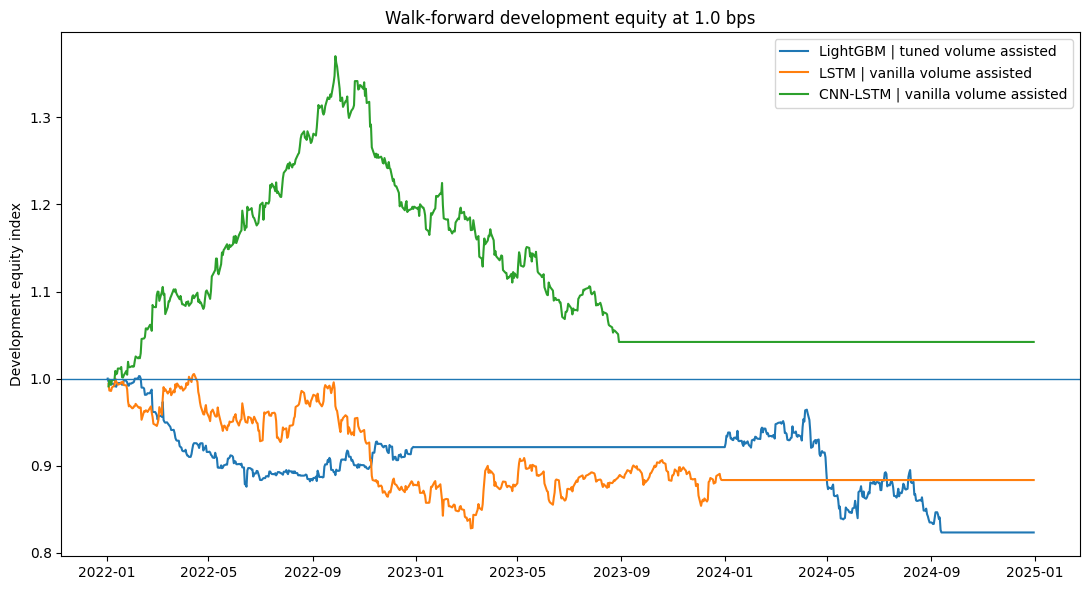

Strategy reconstruction audit: PASS


,model_family,track,fold,reconstructed_net_return,saved_net_return,difference,pass
0,LightGBM,vanilla_price_only,1,-0.011203,-0.011203,-3.483325e-15,True
1,LightGBM,vanilla_price_only,2,-0.133981,-0.133981,-4.829470e-15,True
2,LightGBM,vanilla_price_only,3,-0.141303,-0.141303,4.440892e-16,True
3,LightGBM,vanilla_volume_assisted,1,-0.100950,-0.100950,-4.690692e-15,True
4,LightGBM,vanilla_volume_assisted,2,0.000000,0.000000,0.000000e+00,True
5,LightGBM,vanilla_volume_assisted,3,-0.145670,-0.145670,-8.604228e-16,True
6,LightGBM,tuned_price_only,1,-0.154139,-0.154139,1.387779e-15,True
7,LightGBM,tuned_price_only,2,0.023351,0.023351,-2.806783e-15,True
8,LightGBM,tuned_price_only,3,-0.086900,-0.086900,-7.160939e-15,True
9,LightGBM,tuned_volume_assisted,1,-0.078713,-0.078713,-1.104672e-14,True


In [6]:
def apply_signal_overlay_detailed(
    timestamps: pd.DatetimeIndex,
    p_up: np.ndarray,
    forward_log_returns: np.ndarray,
    upper_threshold: float,
    lower_threshold: float,
    min_hold_bars: int,
    max_position_change_events_per_day: int,
    cost_bps: float,
) -> pd.DataFrame:
    timestamps = pd.DatetimeIndex(timestamps)
    desired = np.where(p_up >= upper_threshold, 1, np.where(p_up <= lower_threshold, -1, 0)).astype(int)
    positions = np.zeros(len(desired), dtype=int)
    net_log_returns = np.zeros(len(desired), dtype=float)
    gross_log_returns = np.zeros(len(desired), dtype=float)
    costs = np.zeros(len(desired), dtype=float)
    turnover_units = np.zeros(len(desired), dtype=float)
    prev_pos = 0
    current_day = None
    daily_log_sum = 0.0
    daily_stop_active = False
    stopped_by_total_dd = False
    bars_since_change = 10**9
    equity_log = 0.0
    peak_equity = 1.0

    for i, ts in enumerate(timestamps):
        day = ts.date()
        if current_day != day:
            current_day = day
            daily_log_sum = 0.0
            daily_stop_active = False
            day_position_change_events = 0

        is_gap = i > 0 and (timestamps[i] - timestamps[i - 1]) != EXPECTED_BAR_DELTA
        if stopped_by_total_dd:
            new_pos = 0
        elif is_gap:
            new_pos = 0
            bars_since_change = 10**9
        elif daily_stop_active:
            new_pos = 0
        else:
            proposed = desired[i]
            can_change_due_to_hold = bars_since_change >= min_hold_bars
            if proposed != prev_pos and can_change_due_to_hold:
                if day_position_change_events < max_position_change_events_per_day:
                    new_pos = proposed
                    day_position_change_events += 1
                    bars_since_change = 0
                else:
                    new_pos = prev_pos
            else:
                new_pos = prev_pos

        turnover = abs(new_pos - prev_pos)
        cost = (cost_bps / 10000.0) * turnover
        gross = new_pos * forward_log_returns[i]
        net = gross - cost

        positions[i] = new_pos
        gross_log_returns[i] = gross
        net_log_returns[i] = net
        costs[i] = cost
        turnover_units[i] = turnover

        equity_log += net
        equity = math.exp(equity_log)
        peak_equity = max(peak_equity, equity)
        drawdown = equity / peak_equity - 1.0
        daily_log_sum += net

        if daily_log_sum <= math.log(1 + DAILY_LOSS_STOP) and not daily_stop_active:
            daily_stop_active = True
        if drawdown <= TOTAL_DRAWDOWN_STOP and not stopped_by_total_dd:
            stopped_by_total_dd = True
        if new_pos == prev_pos:
            bars_since_change += 1
        prev_pos = new_pos

    result = pd.DataFrame({
        'time': timestamps,
        'desired_position': desired,
        'position': positions,
        'gross_log_return': gross_log_returns,
        'cost': costs,
        'net_log_return': net_log_returns,
        'turnover_units': turnover_units,
    })
    result['equity_within_fold'] = np.exp(result['net_log_return'].cumsum())
    result['drawdown_within_fold'] = result['equity_within_fold'] / result['equity_within_fold'].cummax() - 1.0
    return result

reconstruction_rows = []
daily_rows = []
audit_rows = []

for family, payload in source_data.items():
    predictions = payload['tables']['test_predictions_by_track_fold.csv'].copy()
    overlays = payload['tables']['selected_overlay_by_fold.csv'].copy()
    saved_metrics = payload['tables']['test_trading_metrics_by_fold_cost.csv'].copy()

    for track in TRACK_ORDER:
        for fold in [1, 2, 3]:
            pred = predictions[(predictions['track'] == track) & (predictions['fold'] == fold)].sort_values('time').copy()
            selected = overlays[(overlays['track'] == track) & (overlays['fold'] == fold)].iloc[0]
            if selected['selected_action'] == 'stay_flat':
                detailed = pd.DataFrame({
                    'time': pred['time'],
                    'desired_position': 0,
                    'position': 0,
                    'gross_log_return': 0.0,
                    'cost': 0.0,
                    'net_log_return': 0.0,
                    'turnover_units': 0.0,
                })
                detailed['equity_within_fold'] = 1.0
                detailed['drawdown_within_fold'] = 0.0
            else:
                detailed = apply_signal_overlay_detailed(
                    timestamps=pred['time'],
                    p_up=pred['p_up'].to_numpy(),
                    forward_log_returns=pred['target_ret_fwd'].to_numpy(),
                    upper_threshold=float(selected['upper_threshold']),
                    lower_threshold=float(selected['lower_threshold']),
                    min_hold_bars=int(selected['min_hold_bars']),
                    max_position_change_events_per_day=int(selected['max_position_change_events_per_day']),
                    cost_bps=MAIN_COST_BPS,
                )

            reconstructed_return = float(np.exp(detailed['net_log_return'].sum()) - 1.0)
            expected_return = float(saved_metrics[
                (saved_metrics['track'] == track)
                & (saved_metrics['fold'] == fold)
                & np.isclose(saved_metrics['cost_bps'], MAIN_COST_BPS)
            ]['net_return'].iloc[0])
            difference = reconstructed_return - expected_return
            audit_rows.append({
                'model_family': family,
                'track': track,
                'fold': fold,
                'reconstructed_net_return': reconstructed_return,
                'saved_net_return': expected_return,
                'difference': difference,
                'pass': abs(difference) < 1e-9,
            })

            detailed['model_family'] = family
            detailed['track'] = track
            detailed['fold'] = fold
            reconstruction_rows.append(detailed)

            daily = detailed.assign(date=detailed['time'].dt.floor('D')).groupby('date', as_index=False).agg(
                daily_net_log_return=('net_log_return', 'sum'),
                daily_gross_log_return=('gross_log_return', 'sum'),
                daily_cost=('cost', 'sum'),
                active_bars=('position', lambda x: int((x != 0).sum())),
                turnover_units=('turnover_units', 'sum'),
            )
            daily['daily_net_return'] = np.exp(daily['daily_net_log_return']) - 1.0
            daily['model_family'] = family
            daily['track'] = track
            daily['fold'] = fold
            daily_rows.append(daily)

reconstruction_audit = pd.DataFrame(audit_rows)
if not reconstruction_audit['pass'].all():
    display(reconstruction_audit[~reconstruction_audit['pass']])
    raise AssertionError('Strategy reconstruction does not match saved fold metrics.')

strategy_daily_returns = pd.concat(daily_rows, ignore_index=True)
reconstruction_audit.to_csv(TABLE_DIR / 'strategy_reconstruction_audit.csv', index=False)
strategy_daily_returns.to_csv(TABLE_DIR / 'strategy_daily_returns_at_1bps.csv', index=False)

# Equity curve of best active representative from each family.
fig, ax = plt.subplots(figsize=(11, 6))
equity_rows = []
for _, rep in best_active_by_family.iterrows():
    d = strategy_daily_returns[
        (strategy_daily_returns['model_family'] == rep['model_family'])
        & (strategy_daily_returns['track'] == rep['track'])
    ].sort_values('date').copy()
    d['equity'] = np.exp(d['daily_net_log_return'].cumsum())
    d['display_name'] = f"{rep['model_family']} | {rep['track'].replace('_', ' ')}"
    equity_rows.append(d)
    ax.plot(d['date'], d['equity'], label=d['display_name'].iloc[0])
ax.axhline(1.0, linewidth=1)
ax.set_ylabel('Development equity index')
ax.set_title('Walk-forward development equity at 1.0 bps')
ax.legend()
save_figure(fig, 'best_active_by_family_development_equity_1bps')

equity_curves = pd.concat(equity_rows, ignore_index=True)
equity_curves.to_csv(TABLE_DIR / 'best_active_by_family_equity_curves_1bps.csv', index=False)
print('Strategy reconstruction audit: PASS')
display(reconstruction_audit)

## 6. Common-timestamp classification comparison

Neural sequence lengths produce different prediction coverage. To prevent coverage differences from being misread as classification superiority, this section compares corresponding tracks only on timestamps available to all three model families. This is a secondary diagnostic and does not replace native trading performance.

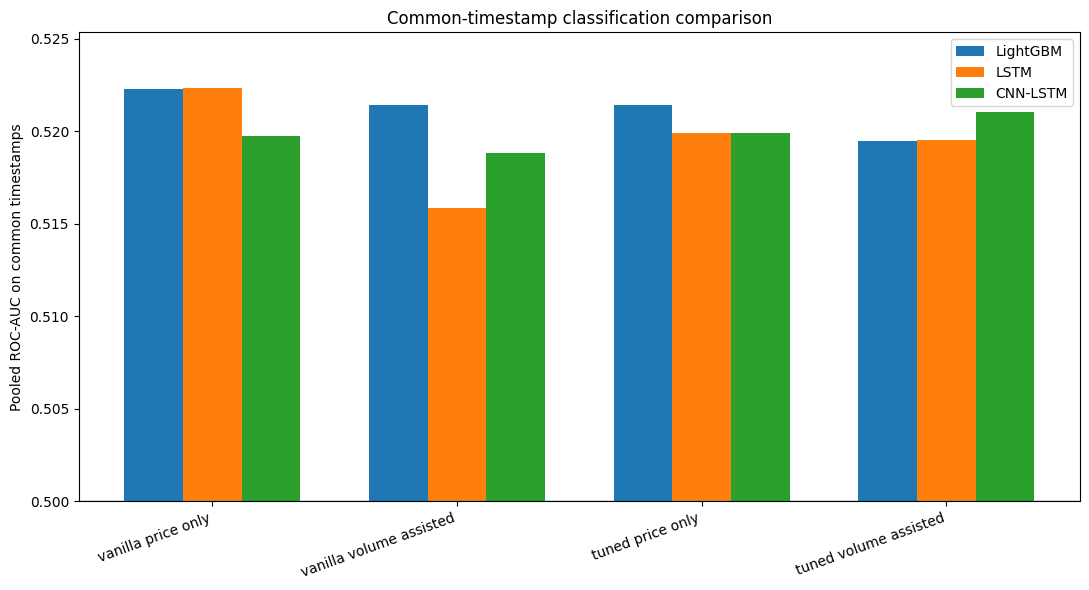

,track,model_family,common_rows,pooled_roc_auc,mean_fold_roc_auc,std_fold_roc_auc,pooled_balanced_accuracy,pooled_brier,pooled_log_loss
6,tuned_price_only,LightGBM,32469,0.521435,0.521001,0.004817,0.514367,0.250123,0.693408
8,tuned_price_only,CNN-LSTM,32469,0.519934,0.519388,0.005968,0.514244,0.250170,0.693499
7,tuned_price_only,LSTM,32469,0.519919,0.518844,0.005074,0.512654,0.250090,0.693336
11,tuned_volume_assisted,CNN-LSTM,24285,0.521046,0.522854,0.011533,0.512146,0.250067,0.693295
10,tuned_volume_assisted,LSTM,24285,0.519526,0.520372,0.006671,0.511467,0.250540,0.694257
9,tuned_volume_assisted,LightGBM,24285,0.519506,0.521248,0.005435,0.513260,0.250092,0.693341
1,vanilla_price_only,LSTM,32471,0.522356,0.522127,0.005412,0.513909,0.250431,0.694038
0,vanilla_price_only,LightGBM,32471,0.522295,0.522485,0.007448,0.513741,0.249890,0.692933
2,vanilla_price_only,CNN-LSTM,32471,0.519743,0.520350,0.007831,0.513563,0.250108,0.693373
3,vanilla_volume_assisted,LightGBM,32471,0.521415,0.521696,0.004749,0.513753,0.250038,0.693234


In [7]:
prediction_tables = {
    family: payload['tables']['test_predictions_by_track_fold.csv'].copy()
    for family, payload in source_data.items()
}

common_fold_rows = []
common_pooled_frames: dict[str, list[pd.DataFrame]] = {track: [] for track in TRACK_ORDER}
correlation_rows = []

for track in TRACK_ORDER:
    for fold in [1, 2, 3]:
        merged = None
        for family, pred_all in prediction_tables.items():
            part = pred_all[(pred_all['track'] == track) & (pred_all['fold'] == fold)][
                ['time', 'p_up', 'target_dir', 'target_ret_fwd']
            ].copy()
            part = part.rename(columns={
                'p_up': f'p_up__{family}',
                'target_dir': f'target__{family}',
                'target_ret_fwd': f'return__{family}',
            })
            merged = part if merged is None else merged.merge(part, on='time', how='inner')

        if merged.empty:
            raise AssertionError(f'No common timestamps for {track}, fold {fold}.')
        target_cols = [f'target__{family}' for family in SOURCE_SPECS]
        return_cols = [f'return__{family}' for family in SOURCE_SPECS]
        if not all((merged[target_cols[0]] == merged[col]).all() for col in target_cols[1:]):
            raise AssertionError(f'Target mismatch on common timestamps for {track}, fold {fold}.')
        if not all(np.allclose(merged[return_cols[0]], merged[col]) for col in return_cols[1:]):
            raise AssertionError(f'Return mismatch on common timestamps for {track}, fold {fold}.')

        y = merged[target_cols[0]].astype(int).to_numpy()
        for family in SOURCE_SPECS:
            p = merged[f'p_up__{family}'].to_numpy()
            pred_label = (p >= 0.5).astype(int)
            common_fold_rows.append({
                'track': track,
                'fold': fold,
                'model_family': family,
                'common_rows': len(merged),
                'roc_auc': roc_auc_score(y, p),
                'balanced_accuracy': balanced_accuracy_score(y, pred_label),
                'brier': brier_score_loss(y, p),
                'log_loss': log_loss(y, p, labels=[0, 1]),
            })
        merged['track'] = track
        merged['fold'] = fold
        common_pooled_frames[track].append(merged)

common_classification_by_fold = pd.DataFrame(common_fold_rows)
summary_rows = []
for track, frames in common_pooled_frames.items():
    pooled = pd.concat(frames, ignore_index=True)
    y = pooled['target__LightGBM'].astype(int).to_numpy()
    prob_cols = [f'p_up__{family}' for family in SOURCE_SPECS]
    corr = pooled[prob_cols].corr()
    for f1 in SOURCE_SPECS:
        for f2 in SOURCE_SPECS:
            correlation_rows.append({
                'track': track,
                'model_family_1': f1,
                'model_family_2': f2,
                'pearson_probability_correlation': float(corr.loc[f'p_up__{f1}', f'p_up__{f2}']),
            })
    for family in SOURCE_SPECS:
        p = pooled[f'p_up__{family}'].to_numpy()
        fold_metrics = common_classification_by_fold[
            (common_classification_by_fold['track'] == track)
            & (common_classification_by_fold['model_family'] == family)
        ]
        summary_rows.append({
            'track': track,
            'model_family': family,
            'common_rows': len(pooled),
            'pooled_roc_auc': roc_auc_score(y, p),
            'mean_fold_roc_auc': fold_metrics['roc_auc'].mean(),
            'std_fold_roc_auc': fold_metrics['roc_auc'].std(ddof=1),
            'pooled_balanced_accuracy': balanced_accuracy_score(y, (p >= 0.5).astype(int)),
            'pooled_brier': brier_score_loss(y, p),
            'pooled_log_loss': log_loss(y, p, labels=[0, 1]),
        })

common_classification_summary = pd.DataFrame(summary_rows)
prediction_correlation = pd.DataFrame(correlation_rows)
common_classification_by_fold.to_csv(TABLE_DIR / 'common_timestamp_classification_by_fold.csv', index=False)
common_classification_summary.to_csv(TABLE_DIR / 'common_timestamp_classification_summary.csv', index=False)
prediction_correlation.to_csv(TABLE_DIR / 'prediction_probability_correlation_by_track.csv', index=False)

# Figure 10: pooled common-timestamp AUC
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(TRACK_ORDER))
width = 0.24
for j, family in enumerate(SOURCE_SPECS):
    fam = common_classification_summary[common_classification_summary['model_family'] == family].set_index('track').loc[TRACK_ORDER]
    ax.bar(x + (j - 1) * width, fam['pooled_roc_auc'], width=width, label=family)
ax.axhline(0.5, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([t.replace('_', ' ') for t in TRACK_ORDER], rotation=20, ha='right')
ax.set_ylabel('Pooled ROC-AUC on common timestamps')
ax.set_title('Common-timestamp classification comparison')
auc_max = common_classification_summary['pooled_roc_auc'].max()
ax.set_ylim(0.5, max(0.525, auc_max + 0.003))
ax.legend()
save_figure(fig, 'common_timestamp_roc_auc_by_track')

display(common_classification_summary.sort_values(['track', 'pooled_roc_auc'], ascending=[True, False]))

## 7. Fixed candidate-selection policy

A model is **strictly eligible** to advance when it satisfies all of the following on the development folds:

1. positive mean net return at 1.0 bps;
2. positive mean net return at 0.5 bps;
3. validation selected active trading in at least two of three test folds;
4. at least one positive test fold at 1.0 bps;
5. mean maximum drawdown remains above the fixed -15% stop;
6. the system is not an all-stay-flat policy.

These requirements deliberately prevent a zero-return all-stay-flat track or a one-fold-only strategy from winning automatically. If several tracks are eligible, they are ranked lexicographically by economic return, breadth of positive evidence, worst-fold performance, validation-to-test stability, drawdown, turnover and finally ROC-AUC.

If no strict candidate exists, the notebook records the fallback tier used rather than silently weakening the standard.

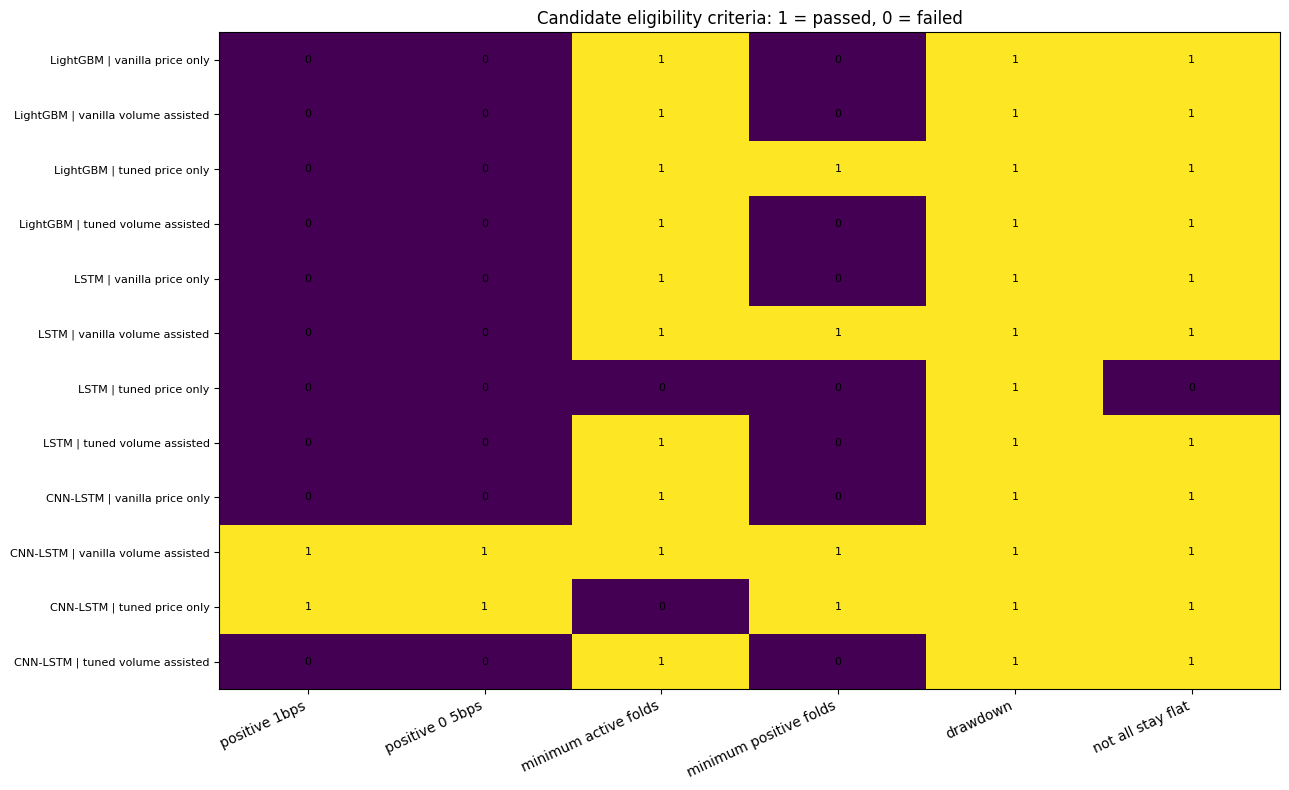

Selected candidate to advance to final holdout:


,selection_tier,model_family,track,feature_set,mode,mean_net_return_0bps,mean_net_return_0_5bps,mean_net_return_1bps,mean_sharpe_1bps,mean_max_drawdown_1bps,positive_fold_count_1bps,active_fold_count,worst_fold_net_return_1bps,mean_roc_auc,breakeven_cost_bps,caution_flag_count,caution_flags
0,strict,CNN-LSTM,vanilla_volume_assisted,volume_assisted,vanilla,0.103714,0.065665,0.022578,-0.039717,-0.095158,1,2,-0.129795,0.517166,1.544921,6,Only one of three development test folds was p...


Caution flags:
- Only one of three development test folds was profitable at 1.0 bps.
- The worst development fold lost at least 10%.
- Mean development Sharpe at 1.0 bps was not positive.
- At least one development fold triggered the total drawdown stop.
- Estimated one-way break-even cost remained below 2 bps.
- The validation gate selected stay-flat in at least one development fold.


In [8]:
eligibility = track_master.copy()
eligibility['criterion_positive_1bps'] = eligibility['mean_net_return_1bps'] > 0
eligibility['criterion_positive_0_5bps'] = eligibility['mean_net_return_0_5bps'] > 0
eligibility['criterion_minimum_active_folds'] = eligibility['active_fold_count'] >= 2
eligibility['criterion_minimum_positive_folds'] = eligibility['positive_fold_count_1bps'] >= 1
eligibility['criterion_drawdown'] = eligibility['mean_max_drawdown_1bps'] > TOTAL_DRAWDOWN_STOP
eligibility['criterion_not_all_stay_flat'] = ~eligibility['all_stay_flat']
criterion_cols = [c for c in eligibility.columns if c.startswith('criterion_')]
eligibility['strictly_eligible'] = eligibility[criterion_cols].all(axis=1)

selection_tier = 'strict'
pool = eligibility[eligibility['strictly_eligible']].copy()
if pool.empty:
    selection_tier = 'fallback_positive_0_5bps_two_active_folds'
    pool = eligibility[
        (eligibility['mean_net_return_0_5bps'] > 0)
        & (eligibility['active_fold_count'] >= 2)
        & (~eligibility['all_stay_flat'])
    ].copy()
if pool.empty:
    selection_tier = 'fallback_positive_0bps_two_active_folds'
    pool = eligibility[
        (eligibility['mean_net_return_0bps'] > 0)
        & (eligibility['active_fold_count'] >= 2)
        & (~eligibility['all_stay_flat'])
    ].copy()
if pool.empty:
    selection_tier = 'fallback_best_active_two_folds'
    pool = eligibility[(eligibility['active_fold_count'] >= 2) & (~eligibility['all_stay_flat'])].copy()
if pool.empty:
    raise RuntimeError('No active candidate is available for final holdout evaluation.')

pool = pool.sort_values(
    by=[
        'mean_net_return_1bps',
        'positive_fold_count_1bps',
        'worst_fold_net_return_1bps',
        'mean_absolute_validation_to_test_decay',
        'mean_max_drawdown_1bps',
        'mean_turnover_units_per_day_1bps',
        'mean_roc_auc',
    ],
    ascending=[False, False, False, True, False, True, False],
)
selected_candidate = pool.iloc[0].copy()

# Explicit caution flags: selection to holdout is not the same as confirmation.
caution_flags = []
if selected_candidate['positive_fold_count_1bps'] < 2:
    caution_flags.append('Only one of three development test folds was profitable at 1.0 bps.')
if selected_candidate['worst_fold_net_return_1bps'] <= -0.10:
    caution_flags.append('The worst development fold lost at least 10%.')
if selected_candidate['mean_sharpe_1bps'] <= 0:
    caution_flags.append('Mean development Sharpe at 1.0 bps was not positive.')
if selected_candidate['drawdown_stop_count_1bps'] > 0:
    caution_flags.append('At least one development fold triggered the total drawdown stop.')
if selected_candidate['breakeven_cost_bps'] < 2.0:
    caution_flags.append('Estimated one-way break-even cost remained below 2 bps.')
if selected_candidate['active_fold_count'] < 3:
    caution_flags.append('The validation gate selected stay-flat in at least one development fold.')

eligibility.to_csv(TABLE_DIR / 'candidate_eligibility_matrix.csv', index=False)
pool.to_csv(TABLE_DIR / 'candidate_ranking_pool.csv', index=False)

candidate_manifest = {
    'notebook_config_version': NOTEBOOK_CONFIG_VERSION,
    'selection_tier': selection_tier,
    'model_family': selected_candidate['model_family'],
    'model_family_key': selected_candidate['model_family_key'],
    'track': selected_candidate['track'],
    'feature_set': selected_candidate['feature_set'],
    'mode': selected_candidate['mode'],
    'main_cost_bps': MAIN_COST_BPS,
    'development_metrics': {
        'mean_net_return_0bps': selected_candidate['mean_net_return_0bps'],
        'mean_net_return_0_5bps': selected_candidate['mean_net_return_0_5bps'],
        'mean_net_return_1bps': selected_candidate['mean_net_return_1bps'],
        'mean_sharpe_1bps': selected_candidate['mean_sharpe_1bps'],
        'mean_max_drawdown_1bps': selected_candidate['mean_max_drawdown_1bps'],
        'positive_fold_count_1bps': int(selected_candidate['positive_fold_count_1bps']),
        'active_fold_count': int(selected_candidate['active_fold_count']),
        'worst_fold_net_return_1bps': selected_candidate['worst_fold_net_return_1bps'],
        'mean_roc_auc': selected_candidate['mean_roc_auc'],
        'breakeven_cost_bps': selected_candidate['breakeven_cost_bps'],
    },
    'caution_flags': caution_flags,
    'final_holdout_status': 'untouched',
    'next_stage': 'Notebook 7 final untouched holdout evaluation',
}
with (CONFIG_DIR / 'selected_candidate_manifest.json').open('w', encoding='utf-8') as handle:
    json.dump(candidate_manifest, handle, indent=2, default=lambda x: x.item() if isinstance(x, np.generic) else x)
with (CONFIG_DIR / 'selection_policy.json').open('w', encoding='utf-8') as handle:
    json.dump(SELECTION_POLICY, handle, indent=2)

selection_result = pd.DataFrame([{
    'selection_tier': selection_tier,
    **{k: selected_candidate[k] for k in [
        'model_family', 'track', 'feature_set', 'mode',
        'mean_net_return_0bps', 'mean_net_return_0_5bps', 'mean_net_return_1bps',
        'mean_sharpe_1bps', 'mean_max_drawdown_1bps', 'positive_fold_count_1bps',
        'active_fold_count', 'worst_fold_net_return_1bps', 'mean_roc_auc', 'breakeven_cost_bps',
    ]},
    'caution_flag_count': len(caution_flags),
    'caution_flags': ' | '.join(caution_flags),
}])
selection_result.to_csv(TABLE_DIR / 'candidate_selection_result.csv', index=False)

# Figure 11: eligibility matrix
matrix = eligibility.set_index('display_name')[criterion_cols].astype(int)
fig, ax = plt.subplots(figsize=(13, 8))
image = ax.imshow(matrix.to_numpy(), aspect='auto', vmin=0, vmax=1)
ax.set_yticks(np.arange(len(matrix)))
ax.set_yticklabels(matrix.index, fontsize=8)
ax.set_xticks(np.arange(len(criterion_cols)))
ax.set_xticklabels([c.replace('criterion_', '').replace('_', ' ') for c in criterion_cols], rotation=25, ha='right')
ax.set_title('Candidate eligibility criteria: 1 = passed, 0 = failed')
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, str(matrix.iloc[i, j]), ha='center', va='center', fontsize=8)
save_figure(fig, 'candidate_eligibility_matrix')

print('Selected candidate to advance to final holdout:')
display(selection_result)
print('Caution flags:')
for flag in caution_flags:
    print('-', flag)

## 8. Report-ready outputs and final development finding

In [9]:
figure_index = pd.DataFrame([
    ['cross_model_all_tracks_net_return_1bps', 'Mean development net return of all harmonised model tracks at a one-way transaction cost of 1.0 bps.', 'Shows the economic ranking at the main cost assumption.'],
    ['best_active_by_family_cost_curve', 'Transaction-cost sensitivity of the best active LightGBM, LSTM and CNN-LSTM tracks.', 'Shows whether development performance survives realistic friction.'],
    ['best_active_by_family_fold_returns_1bps', 'Annual walk-forward test returns of the best active track from each model family at 1.0 bps.', 'Shows regime stability and concentration of returns.'],
    ['best_active_by_family_development_equity_1bps', 'Reconstructed walk-forward development equity of the best active family representatives at 1.0 bps.', 'Shows the sequence of gains, losses and stay-flat periods.'],
    ['cross_model_all_tracks_roc_auc', 'Mean native ROC-AUC of all harmonised model tracks.', 'Shows that classification differences are small and do not directly determine trading profitability.'],
    ['common_timestamp_roc_auc_by_track', 'ROC-AUC comparison on timestamps shared by all three model families.', 'Controls for unequal sequence coverage.'],
    ['cross_model_risk_return_scatter_1bps', 'Mean net return versus absolute mean maximum drawdown at 1.0 bps.', 'Shows the development risk-return trade-off.'],
    ['cross_model_absolute_validation_to_test_decay', 'Mean absolute return change from overlay validation to unseen test periods.', 'Shows generalisation stability.'],
    ['cross_model_selected_trade_rate', 'Proportion of development folds in which the validation gate selected active trading.', 'Distinguishes active evidence from stay-flat protection.'],
    ['best_active_by_family_breakeven_cost', 'Estimated one-way break-even transaction cost of the best active family representatives.', 'Summarises cost tolerance.'],
    ['candidate_eligibility_matrix', 'Pass/fail matrix for the fixed candidate-selection requirements.', 'Makes final development selection transparent and reproducible.'],
], columns=['figure_stem', 'suggested_caption', 'main_message'])
figure_index.to_csv(TABLE_DIR / 'report_figure_index.csv', index=False)

selected_name = f"{selected_candidate['model_family']} {selected_candidate['track'].replace('_', ' ')}"
findings_lines = [
    'Notebook 6 — Harmonised cross-model development comparison',
    '',
    'Framework integrity',
    '- Final harmonised LightGBM, LSTM and CNN-LSTM outputs were loaded successfully.',
    '- The three model families used identical walk-forward folds, inner model-validation roles, outer overlay-validation roles, transaction-cost assumptions, overlay grids and risk controls.',
    '- The final 2025-01-01 to 2026-03-31 holdout was not accessed.',
    '',
    'Primary development finding',
    f'- The selected candidate is {selected_name}.',
    f'- Selection tier: {selection_tier}.',
    f"- Mean net return: {selected_candidate['mean_net_return_0bps']:.4%} at 0 bps, {selected_candidate['mean_net_return_0_5bps']:.4%} at 0.5 bps and {selected_candidate['mean_net_return_1bps']:.4%} at 1.0 bps.",
    f"- Mean Sharpe at 1.0 bps: {selected_candidate['mean_sharpe_1bps']:.4f}.",
    f"- Mean maximum drawdown at 1.0 bps: {selected_candidate['mean_max_drawdown_1bps']:.4%}.",
    f"- Positive development folds at 1.0 bps: {int(selected_candidate['positive_fold_count_1bps'])}/3.",
    f"- Active development folds: {int(selected_candidate['active_fold_count'])}/3.",
    f"- Estimated one-way break-even cost: {selected_candidate['breakeven_cost_bps']:.3f} bps.",
    '',
    'Interpretation',
    '- The candidate advances because it is the only strict eligible system under the fixed development-selection policy.',
    '- It should be treated as a provisional candidate, not as proof of profitability or deployment readiness.',
    '- The final holdout must be evaluated once with no post-hoc changes.',
    '',
    'Caution flags',
]
findings_lines.extend([f'- {flag}' for flag in caution_flags])
findings_lines.extend([
    '',
    'Next step',
    '- Freeze the selected model family, feature track, architecture policy, cost assumptions and overlay policy.',
    '- Proceed to Notebook 7 for one final untouched holdout evaluation.',
])
findings = '\n'.join(findings_lines) + '\n'

with (OUTPUT_DIR / 'cross_model_comparison_findings_draft.txt').open('w', encoding='utf-8') as handle:
    handle.write(findings)

print(findings)
print('\nNotebook 6 outputs saved to:', OUTPUT_DIR)
display(figure_index)

Notebook 6 — Harmonised cross-model development comparison

Framework integrity
- Final harmonised LightGBM, LSTM and CNN-LSTM outputs were loaded successfully.
- The three model families used identical walk-forward folds, inner model-validation roles, outer overlay-validation roles, transaction-cost assumptions, overlay grids and risk controls.
- The final 2025-01-01 to 2026-03-31 holdout was not accessed.

Primary development finding
- The selected candidate is CNN-LSTM vanilla volume assisted.
- Selection tier: strict.
- Mean net return: 10.3714% at 0 bps, 6.5665% at 0.5 bps and 2.2578% at 1.0 bps.
- Mean Sharpe at 1.0 bps: -0.0397.
- Mean maximum drawdown at 1.0 bps: -9.5158%.
- Positive development folds at 1.0 bps: 1/3.
- Active development folds: 2/3.
- Estimated one-way break-even cost: 1.545 bps.

Interpretation
- The candidate advances because it is the only strict eligible system under the fixed development-selection policy.
- It should be treated as a provisional candidate,

,figure_stem,suggested_caption,main_message
0,cross_model_all_tracks_net_return_1bps,Mean development net return of all harmonised ...,Shows the economic ranking at the main cost as...
1,best_active_by_family_cost_curve,Transaction-cost sensitivity of the best activ...,Shows whether development performance survives...
2,best_active_by_family_fold_returns_1bps,Annual walk-forward test returns of the best a...,Shows regime stability and concentration of re...
3,best_active_by_family_development_equity_1bps,Reconstructed walk-forward development equity ...,"Shows the sequence of gains, losses and stay-f..."
4,cross_model_all_tracks_roc_auc,Mean native ROC-AUC of all harmonised model tr...,Shows that classification differences are smal...
5,common_timestamp_roc_auc_by_track,ROC-AUC comparison on timestamps shared by all...,Controls for unequal sequence coverage.
6,cross_model_risk_return_scatter_1bps,Mean net return versus absolute mean maximum d...,Shows the development risk-return trade-off.
7,cross_model_absolute_validation_to_test_decay,Mean absolute return change from overlay valid...,Shows generalisation stability.
8,cross_model_selected_trade_rate,Proportion of development folds in which the v...,Distinguishes active evidence from stay-flat p...
9,best_active_by_family_breakeven_cost,Estimated one-way break-even transaction cost ...,Summarises cost tolerance.


## Chairman interpretation

Notebook 6 should be considered complete only when:

- all source and reconstruction audits pass;
- the selection policy returns exactly one candidate;
- no final-holdout row appears anywhere;
- the candidate manifest is saved;
- the report figures and comparison tables are generated.

The selected candidate is allowed to fail on the final holdout. A negative final result would still be an academically valid and important finding. The methodology must not be redesigned after viewing the final holdout.